In [1]:
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_path = '/content/drive/MyDrive/Colab Notebooks/transfer learning/train'

# 이미지 변형 정의: 모델이 학습하기 좋은 형태로 이미지 처리
transform = transforms.Compose(
    [
        transforms.Resize([256, 256]),  # 이미지 256x256 크기로 고정(비율 유지X)
        transforms.RandomResizedCrop(224),  # 무작위로 일부 영역 잘라내어 224x224 크기로 조정(데이터 증강 효과)
        transforms.RandomHorizontalFlip(),  # 50%의 확률로 이미지 좌우 반전(모델의 일반화 성능 향상)
        transforms.ToTensor() # 이미지를 Tensor 형식으로 변환하고 픽셀 값을 0~1 사이로 정규화
    ])

# ImageFolder: 폴더 구조를 기반으로 데이터셋 생성
# 폴더명이 클래스(Label)가 되며, 위에서 정의한 transform을 적용
train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)

# ImageFolder(train_dataset)을 데이터로더에 할당
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=2,  # 코렙 권장치 = 2
    shuffle=True
)

print(len(train_dataset))

385


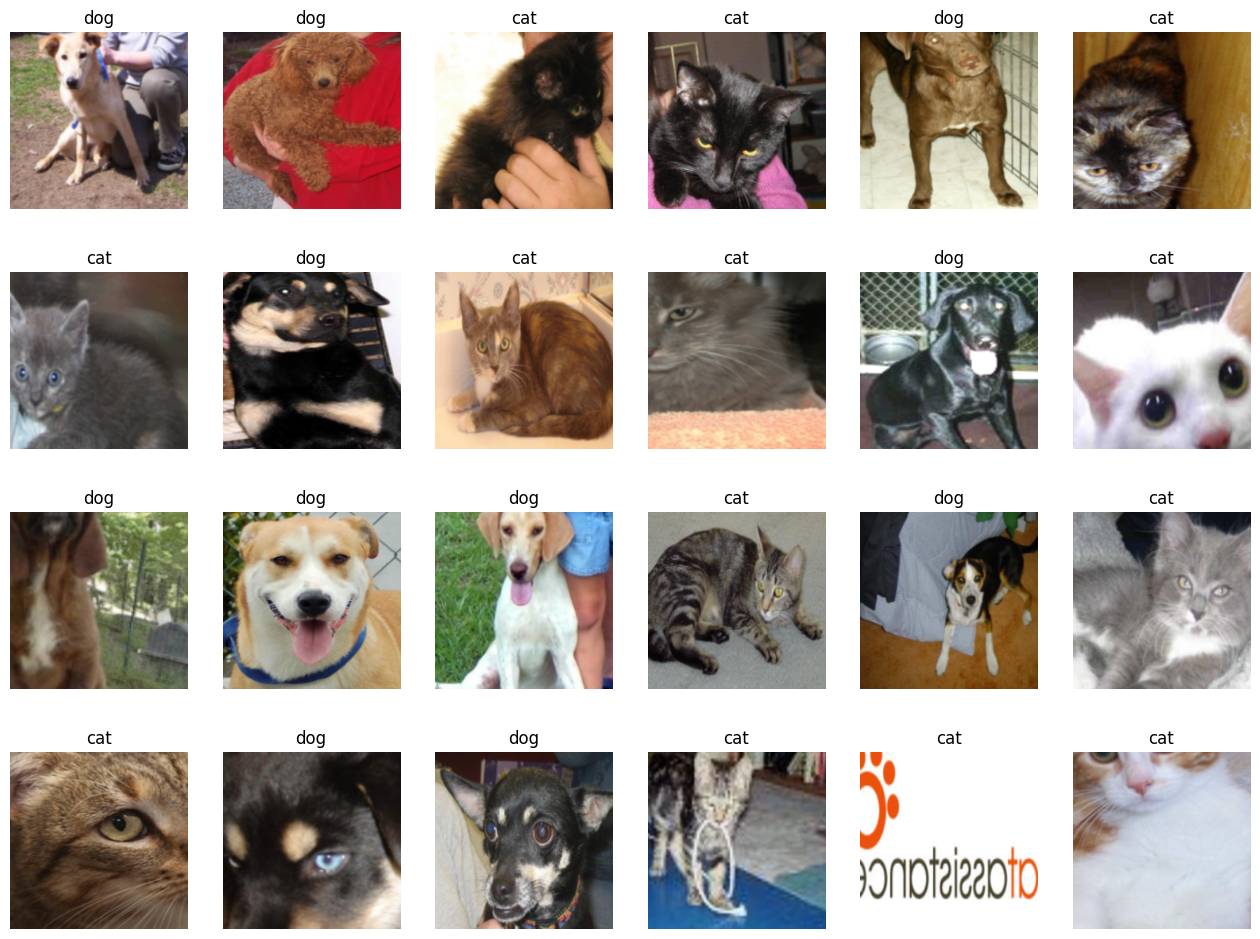

In [3]:
# DataLoader에서 첫 번째 데이터 배치(32장의 이미지와 라벨)를 가져옴
# iter()로 반복자를 만들고 next()로 그 안의 첫 번째 요소를 추
samples, labels = next(iter(train_loader))
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16, 24))
for i in range(24):
  a = fig.add_subplot(4, 6, i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')

  # sample[i]는 PyTorch 텐서 형태(C, H, W)이다.
  # .numpy()로 넘파이 배열로 바꾸고, np.transpose를 사용하여 matplotlib이 인식할 수 있는 (H, W, C) 순서로 차원을 맞바꾼 후 출력
  a.imshow(np.transpose(samples[i].numpy(), (1, 2, 0)))

# bottom/top: 도화지 내에서 그림이 차지할 수직 범위, hspace: 그림들 사이의 세로 간격
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

In [4]:
# pretrained=True: 사전 학습된 가중치를 사용하겠다라는 의미
resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 239MB/s]


In [5]:
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      # 해당 매개변수의 학습(기울기 계산)을 비활성화
      # False로 설정하면 역전파 시 가중치가 업데이트되지 않음
      param.requires_grad = False

set_parameter_requires_grad(resnet18)

In [6]:
resnet18.fc = nn.Linear(512, 2)

In [7]:
# named_parameters(): 모델에 접근하여 파라미터 값들을 가져올 때 사용
for name, param in resnet18.named_parameters():
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[-0.0428, -0.0029, -0.0150,  ..., -0.0327, -0.0052, -0.0293],
        [ 0.0396,  0.0399,  0.0258,  ..., -0.0310, -0.0312,  0.0247]])
fc.bias tensor([0.0190, 0.0241])


In [8]:
# 모델의 객체 생성
# ImageNet V1 가중치 가져오기
model = models.resnet18(weights='IMAGENET1K_V1')

for param in model.parameters():  # 모델의 합성곱 가중치 고정
  param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters(): # 완전연결층은 학습
  param.requires_grad = True

# 모델 전체가 아니라 학습 가능한 model.fc.parameters()만 전달
# 이렇게 하면 Adam 알고리즘이 마지막 층의 가중치만 업데이트한다.
optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
  since = time.time() # 학습 시간 기록(전체 소요 시간 계산)
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-' * 10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad() # 이전 기울기를 0으로 초기화
      outputs = model(inputs) # 모델에 데이터를 넣어 예측값 계
      loss = criterion(outputs, labels) # 예측값과 실제 정답 사이의 오차 계산
      _, preds = torch.max(outputs, 1)  # 예측값 중 가장 높은 확률을 가진 인덱스(클래스) 추출
      loss.backward() # 역전파 학습
      optimizer.step()  # 실제로 가중치를 조금씩 움직여 오차를 줄이는 단계

      # inputs.size(0)를 곱하는 이유: criterion에서 계산된 손실은 배치당 평균값이다.
      # 전체 데이터셋의 평균을 구하기 위해 다시 배치의 크기를 곱해 총합으로 만든 뒤 나중에 전체 개수로 나누는 것
      running_loss += loss.item() * inputs.size(0)  # 출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
      running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하며 저장

    epoch_loss = running_loss / len(dataloaders.dataset)  # 평균 오차 계산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset)  # 평균 정확도 계산

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('/content/drive/MyDrive/Colab Notebooks/transfer learning', '{0:0=2d}.pth'.format(epoch)))  # 모델 재사용을 위해 저장
    print()

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history

In [10]:
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True: # 학습 활성화
    params_to_update.append(param)
    print("\t", name)

# 모델 전체가 아니라 위에서 골라낸 업데이트 대상만 Adam 알고리즘에 전달
# 이렇게 하면 기울기 계산과 가중치 수정이 이 파라미터들에 대해서만 일어남
optimizer = optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.6237 Acc: 0.6338

Epoch 1/12
----------
Loss: 0.3653 Acc: 0.8779

Epoch 2/12
----------
Loss: 0.3117 Acc: 0.8831

Epoch 3/12
----------
Loss: 0.2811 Acc: 0.8779

Epoch 4/12
----------
Loss: 0.2582 Acc: 0.9065

Epoch 5/12
----------
Loss: 0.2078 Acc: 0.9325

Epoch 6/12
----------
Loss: 0.2544 Acc: 0.8961

Epoch 7/12
----------
Loss: 0.2011 Acc: 0.9299

Epoch 8/12
----------
Loss: 0.2211 Acc: 0.9091

Epoch 9/12
----------
Loss: 0.2508 Acc: 0.8831

Epoch 10/12
----------
Loss: 0.1895 Acc: 0.9325

Epoch 11/12
----------
Loss: 0.2029 Acc: 0.9325

Epoch 12/12
----------
Loss: 0.2128 Acc: 0.9117

Training complete in 6m 38s
Best Acc: 0.932468


In [12]:
test_path = '/content/drive/MyDrive/Colab Notebooks/transfer learning/test'

# 테스트 데이터에 적용할 이미지 전처리(transform) 정의
# 모델(ResNet18)이 학습할 때 사용했던 것과 동일한 규격으로 맞춰야 정확한 평가가 가
transform = transforms.Compose(
    [
        transforms.Resize(224), # 이미지의 짧은 쪽을 224 픽셀로 맞추어 크기 조정
        transforms.CenterCrop(224), # 이미지 중앙을 기준으로 224x224 크기로 잘라냄(정사각형 형태)
        transforms.ToTensor(),  # 이미지를 0~1 사이의 값을 가진 PyTorch 텐서로 변환
    ])

test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)

# 데이터셋을 배치 단위로 쪼개서 불러오는 DataLoader 생성
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


In [13]:
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0

  # 지정된 경로에서 .pth인 모든 파일 목록을 가져옴
  # glob: 현재 디렉터리에서 원하는 파일들만 추출하여 가져올 때 사용한다.
  saved_models = glob.glob('/content/drive/MyDrive/Colab Notebooks/transfer learning/' + '*.pth')
  saved_models.sort()
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    # 저장된 가중치(state_dict)를 모델 객체에 로드
    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    # 테스트 데이터로 추론 시작
    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      # 평가 시에는 기울기를 계산할 필요가 없으므로 메모리 절약을 위해 설정
      with torch.no_grad():
        outputs = model(inputs) # 모델의 예측 결과(Logits)

      # 최종 결과 도출
      # outputs.data에서 가장 큰 값의 인덱스를 찾아 예측 클래스(0 또는 1) 결정
      _, preds = torch.max(outputs.data, 1)
      preds[preds >= 0.5] = 1
      preds[preds < 0.5] = 0

      # 예측값과 실제 정답이 일치하는 개수를 합산
      # labels.cpu(): 계산을 위해 정답 데이터를 CPU로 옮김
      running_corrects += preds.eq(labels.cpu()).int().sum()

    epoch_acc = running_corrects.double() / len(dataloaders.dataset)
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    print()

  time_elapsed = time.time() - since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history

In [14]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/drive/MyDrive/Colab Notebooks/transfer learning/00.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/01.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/02.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/03.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/04.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/05.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/06.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/07.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/08.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/09.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/10.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/11.pth', '/content/drive/MyDrive/Colab Notebooks/transfer learning/12.pth']
Loading model /content/drive/MyDrive/Colab Notebooks/transfer learning/00.pth
Acc: 0.8980

Loading model /content/dr

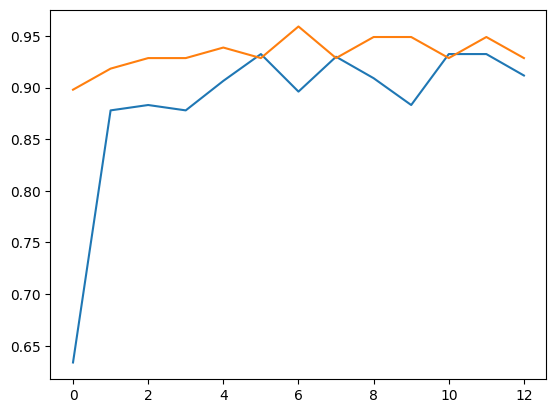

In [15]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

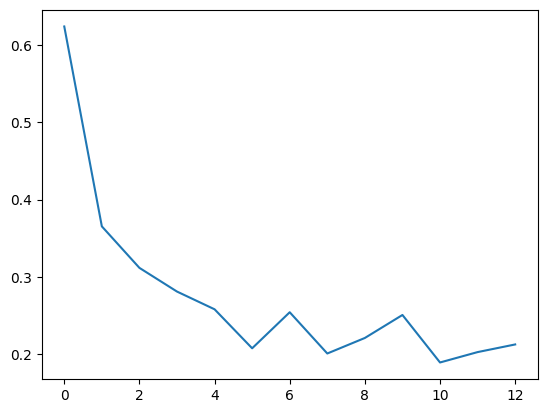

In [16]:
plt.plot(train_loss_hist)
plt.show()

In [17]:
def im_convert(tensor):
  # 텐서를 복제(clone)하고 연산 그래프에서 분리(detach)한 뒤 Numpy 배열로 변환
  # 학습용 데이터는 기울기 정보를 포함하고 있어 직접 변환이 안되므로 복제(clone) 후 분리(detach)가 필요함
  image = tensor.clone().detach().numpy()

  # 차원의 순서를 변경(PyTorch: [C, H, W] -> 일반 이미지: [H, W, C])
  # 0번(Channel)을 맨 뒤로 보내야 matplotlib 등에서 정상적으로 출력됨
  image = image.transpose(1, 2, 0)

  # 역정규화(De-normalization)
  # 이미지 처리 시 0~1 사이로 만들었던 값을 원래 색상 값으로 되돌리는 과정
  # 여기서는 (이미지*표준편차) + 평균과 같은 원리로 원래의 픽셀 분포를 복구함
  image = image * (np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)))

  # 값의 범위를 0~1 사이로 제한(Clipping)
  # 역산 과정에서 0보다 작아지거나 1보다 커진 값을 각각 0과 1로 고정하여 이미지 깨짐 방지
  image = image.clip(0, 1)
  return image

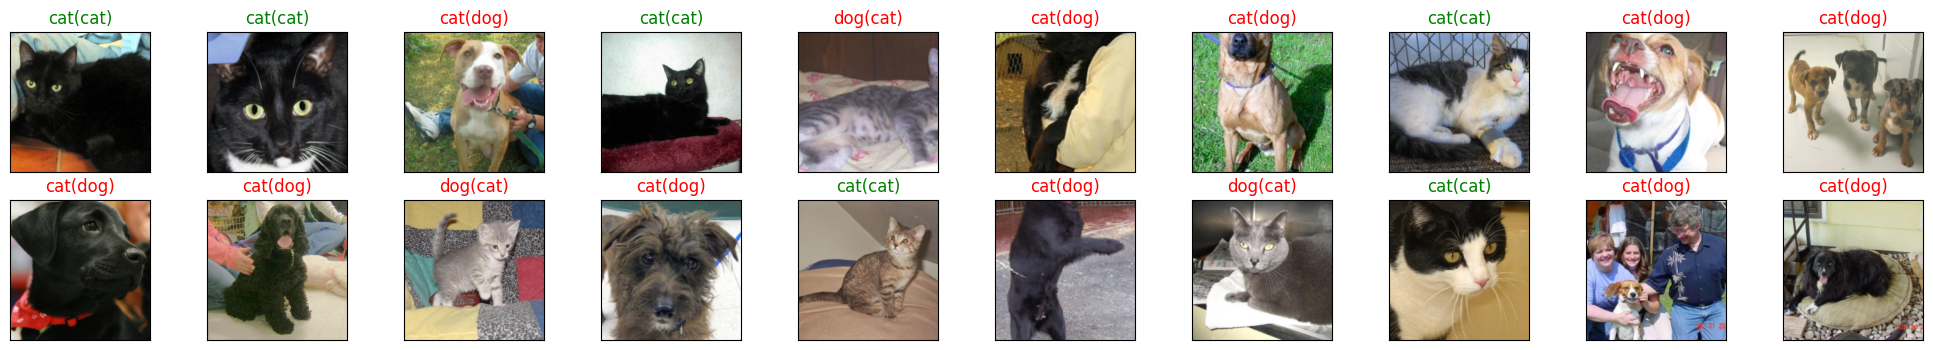

<Figure size 640x480 with 0 Axes>

In [18]:
classes = {0:'cat', 1:'dog'}

dataiter = iter(test_loader)
images, labels = next(dataiter)
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])

  # 이전에 정의한 im_convert 함수를 사용하여 텐서를 이미지로 변환 후 출력
  plt.imshow(im_convert(images[idx]))

  # 정답을 맞히면 초록색, 틀리면 빨간색으로 지정
  a.set_title(classes[labels[i].item()])
  ax.set_title("{}({})".format(
      str(classes[preds[idx].item()]),  # 모델의 예측 결과
      str(classes[labels[idx].item()])  # 실제 정답
  ), color=("green" if preds[idx]==labels[idx] else "red"))

plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)